### **KPI och visualisering**
**KPI 1 - Bokningsaktivitet**
- Antal bokningar per månad - Visar när verksamheten är som mest aktiv
        
**KPI 2 - Ekonomisk prestation**
- Beräknade intäkter per månad, baserat på medlemmarnas månadskostnader
        
**KPI 3 - Kundbehållning**
- Antal avhopp per månad - Identifierar problemmånader


In [1]:
# Importera bibliotek
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Läs in all data från SQLite
conn = sqlite3.connect('friskvard_data_cleaned.db')
df_all = pd.read_sql('SELECT * FROM friskvard_data', conn)
conn.close

# Skapa en kopia för feature engineering
df_feat = df_all.copy()

In [3]:
df_feat.head()

,bokning_id,medlem_id,medlemstyp,medlem_startdatum,medlem_slutdatum,månadskostnad,födelseår,pass_id,passnamn,anläggning,instruktör,bokningsdatum,passdatum,passtid,status,feedback_text,feedbackdatum,feedback_betyg,är_negativt_belopp,månadskostnad_abs
0,BOK-000001,MED-10158,Premium,2023-07-29 00:00:00,2025-07-03 00:00:00,599,2006.0,PASS-2024-10-01-001,Yoga,Göteborg Centrum,Maria Santos,2024-09-24 00:00:00,2024-10-01 00:00:00,11:00:00.000000,Genomförd,Bästa yogapasset jag varit på. Kommer tillbaka!,2024-10-02 00:00:00,4.0,0,599
1,BOK-000002,MED-10229,Premium,2023-08-01 00:00:00,2025-06-26 00:00:00,599,1984.0,PASS-2024-12-04-002,Spinning,Malmö Centrum,Johan Bergström,2024-11-27 00:00:00,2024-12-04 00:00:00,10:00:00.000000,Genomförd,Professionellt och välorganiserat pass.,2024-12-05 00:00:00,5.0,0,599
2,BOK-000003,MED-10223,Student,2023-12-27 00:00:00,2025-05-12 00:00:00,249,2006.0,PASS-2024-11-09-003,Styrketräning,Okänd,Erik Johansson,2024-11-08 00:00:00,2024-11-09 00:00:00,18:00:00.000000,Genomförd,,None,NaN,0,249
3,BOK-000004,MED-10110,Bas,2023-07-03 00:00:00,2025-03-24 00:00:00,349,2006.0,PASS-2024-09-04-004,Pilates,Göteborg Centrum,Maria Santos,2024-09-01 00:00:00,2024-09-04 00:00:00,07:00:00.000000,Genomförd,Professionellt och välorganiserat pass.,2024-09-02 00:00:00,5.0,0,349
4,BOK-000005,MED-10022,Premium,2022-11-05 00:00:00,2025-06-01 00:00:00,599,1992.0,PASS-2024-10-29-005,Pilates,Västerås,Klara Svensson,2024-10-26 00:00:00,2024-10-29 00:00:00,20:30:00.000000,Genomförd,Bästa pilatespasset jag varit på. Kommer tillb...,2024-10-30 00:00:00,5.0,0,599


In [9]:
# Skapa månadskolumn
df_feat['månad'] = df_feat['passdatum'].dt.strftime('%Y-%m')

# Filtrera för juli-dec 2024
månader = ['2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']
period = df_feat[df_feat['månad'].isin(månader)].copy()

# Förbered data för diagram
månadsnamn = ['Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec']

# KPI 1: Bokningar per månad
bokningar = period.groupby('månad').size().reindex(månader, fill_value=0)

# KPI 2: Intäkter per månad (simplifierat)
medlemsinfo = period[['medlem_id', 'månadskostnad', 'månad']].drop_duplicates()
intäkter = medlemsinfo.groupby('månad')['månadskostnad'].sum().reindex(månader, fill_value=0)

# KPI 3: Avhopp per månad
period['avhopp_månad'] = period['medlem_slutdatum'].dt.strftime('%Y-%m')
avhopp_data = period[period['avhopp_månad'].notna()].groupby('avhopp_månad').size()
avhopp = pd.Series([0]*6, index=månader)
for månad, antal in avhopp_data.items():
    if månad in avhopp.index:
        avhopp[månad] = antal

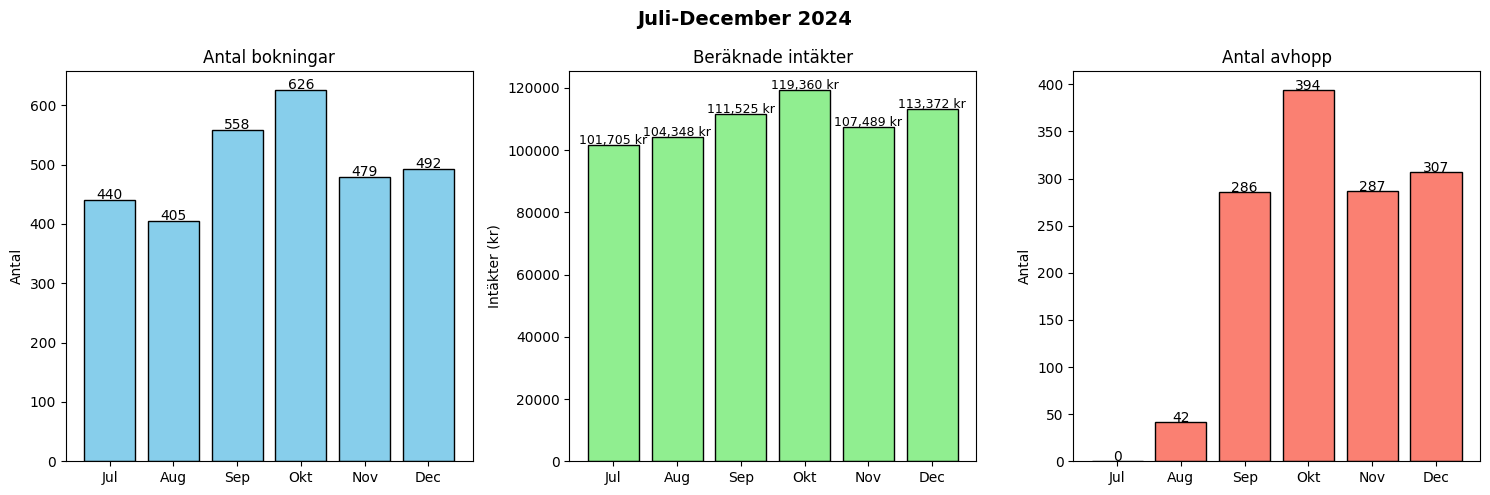

SUMMERING JULI-DEC 2024
Totalt bokningar: 3000
Unika medlemmar: 375
Beräknade intäkter: 657,799 kr
Totala avhopp: 1316


In [11]:
# Skapa Diagram
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Diagram 1
ax1.bar(månadsnamn, bokningar, color='skyblue', edgecolor='black')
ax1.set_title('Antal bokningar')
ax1.set_ylabel('Antal')
for i, v in enumerate(bokningar):
    ax1.text(i, v + 2, str(v), ha='center')

# Diagram 2  
ax2.bar(månadsnamn, intäkter, color='lightgreen', edgecolor='black')
ax2.set_title('Beräknade intäkter')
ax2.set_ylabel('Intäkter (kr)')
for i, v in enumerate(intäkter):
    ax2.text(i, v + 300, f'{v:,.0f} kr', ha='center', fontsize=9)

# Diagram 3
ax3.bar(månadsnamn, avhopp, color='salmon', edgecolor='black')
ax3.set_title('Antal avhopp')
ax3.set_ylabel('Antal')
for i, v in enumerate(avhopp):
    ax3.text(i, v + 0.2, str(v), ha='center')

plt.suptitle('Juli-December 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Summering
print("="*50)
print("SUMMERING JULI-DEC 2024")
print("="*50)
print(f"Totalt bokningar: {len(period)}")
print(f"Unika medlemmar: {period['medlem_id'].nunique()}")
print(f"Beräknade intäkter: {intäkter.sum():,.0f} kr")
print(f"Totala avhopp: {avhopp.sum()}")
print("="*50)

In [ ]:
# === Sätt upp API-nyckel ===
# Läsa miljövariablar
import os
# Hantera filsökvägar
from pathlib import Path
# Ladda .env-filer                 
from dotenv import load_dotenv  

# Ladda .env från samma mapp som notebooken
env_path = Path().cwd() / ".env"
load_dotenv(env_path, override=True)

api_key = os.getenv("GROQ_API_KEY")
print(f"API Key loaded: {api_key is not None}")

✅ API Key loaded: True


In [13]:
# === Initiera LLM-modell ===
# Importera langchain_groq för textanalys
from langchain_groq import ChatGroq  

try:
    llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0
    )
    
    if llm:
        print("LLM is initialized")
except Exception as e:
    print(f"Error: {e}")

c:\Users\johan\Data Manager\Data science VScode\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\johan\Data Manager\Data science VScode\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM is initialized


In [14]:
# Testa LLM med en enkel fråga
response = llm.invoke("Vad är huvudstaden i Thailand?")
response.content

'Huvudstaden i Thailand är Bangkok.'

In [15]:
# System prompt för feedbackanalys
system_prompt = """Du är en feedbackanalytiker för en friskvårdscenter/gym. Svara endast på svenska.

INSTRUKTIONER:
1. Extrahera information från medlemmars feedback
2. Svara ENDAST med en valid JSON-struktur - ingenting annat före eller efter
3. Använd EXAKT denna JSON-format:

{
    "sammanfattning": "En mening med sammanfattning av feedbacken",
    "kategori": "Instruktörer|Träning|Utrustning|Anläggning|Schema|Medlemskap|Annat",
    "sentiment": "POSITIV|NEGATIV|NEUTRAL",
    "prioritet": 1
}

Du MÅSTE svara med ENDAST JSON. Ingen text före eller efter. Ingen förklaring. BARA JSON.

EXEMPEL:
input: "Instruktören kunde inte visa korrekt teknik"
output: 
{
    "sammanfattning": "Medlem är missnöjd med instruktörens tekniska vägledning", 
    "kategori": "Instruktörer", 
    "sentiment": "NEGATIV", 
    "prioritet": 4
}
"""

In [17]:
# Testa system prompt och JSON-svar
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": "Ska ett gym vara rent?"}
]

response = llm.invoke(messages)
print(response.content)

{
    "sammanfattning": "Medlemmen tycker att gymmet bör vara rent",
    "kategori": "Anläggning",
    "sentiment": "POSITIV",
    "prioritet": 3
}


In [18]:
import json

try:
    result = json.loads(response.content)
    print(result)
except json.JSONDecodeError as e:
    print(f"Error decoding JSON: {e}")


{'sammanfattning': 'Medlemmen tycker att gymmet bör vara rent', 'kategori': 'Anläggning', 'sentiment': 'POSITIV', 'prioritet': 3}


In [19]:
results = []

for index, row in feedback_data.head(20).iterrows():
    text = row["feedback_text"]
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text}]

    answer = llm.invoke(messages)

    try:
        result = json.loads(answer.content)
        results.append(result)
    except json.JSONDecodeError as e:
        print(f"Fel vid JSON-parsning: {e}. Svar: {answer.content}")

results_df = pd.DataFrame(results)
results_df

,sammanfattning,kategori,sentiment,prioritet
0,Medlem är mycket nöjd med yogapasset,Instruktörer,POSITIV,1
1,Medlem är nöjd med passets organisation och pr...,Instruktörer,POSITIV,1
2,Ingen feedback angiven,Annat,NEUTRAL,1
3,Medlem är nöjd med passets professionella och ...,Instruktörer,POSITIV,1
4,Medlem är mycket nöjd med pilatespasset,Träning,POSITIV,1
5,Inga specifika detaljer angivna,Annat,NEUTRAL,1
6,Ingen feedback angiven,Annat,NEUTRAL,1
7,Inga specifika detaljer angivna,Annat,NEUTRAL,1
8,Ingen feedback angiven,Annat,NEUTRAL,1
9,Medlem tycker att utmaningen var för låg,Träning,NEGATIV,3
